In [1]:
import numpy as np
import pandas as pd

train = pd.read_csv('/kaggle/input/datasets/veeenz3/widsdatathon2020/widsdatathon2020/training_v2.csv')
print(train.shape)
print(train.head())

(91713, 186)
   encounter_id  patient_id  hospital_id  hospital_death   age    bmi  \
0         66154       25312          118               0  68.0  22.73   
1        114252       59342           81               0  77.0  27.42   
2        119783       50777          118               0  25.0  31.95   
3         79267       46918          118               0  81.0  22.64   
4         92056       34377           33               0  19.0    NaN   

   elective_surgery  ethnicity gender  height  ... aids cirrhosis  \
0                 0  Caucasian      M   180.3  ...  0.0       0.0   
1                 0  Caucasian      F   160.0  ...  0.0       0.0   
2                 0  Caucasian      F   172.7  ...  0.0       0.0   
3                 1  Caucasian      F   165.1  ...  0.0       0.0   
4                 0  Caucasian      M   188.0  ...  0.0       0.0   

   diabetes_mellitus hepatic_failure immunosuppression  leukemia  lymphoma  \
0                1.0             0.0               0.0 

In [2]:
print(train['hospital_death'].value_counts())
print(train['hospital_death'].value_counts(normalize=True))

hospital_death
0    83798
1     7915
Name: count, dtype: int64
hospital_death
0    0.913698
1    0.086302
Name: proportion, dtype: float64


In [3]:
missing = train.isnull().sum()
print(missing[missing>0].sort_values(ascending=False))

h1_bilirubin_max    84619
h1_bilirubin_min    84619
h1_lactate_max      84369
h1_lactate_min      84369
h1_albumin_min      83824
                    ...  
d1_sysbp_max          159
d1_heartrate_max      145
d1_heartrate_min      145
icu_admit_source      112
gender                 25
Length: 175, dtype: int64


In [4]:
threshold = 0.7
missing_pct = train.isnull().mean()
high_missing = missing_pct[missing_pct>threshold]
print(f'columns with more than 70% missing values: {len(high_missing)}')
print(high_missing.sort_values(ascending=False))

columns with more than 70% missing values: 55
h1_bilirubin_min          0.922650
h1_bilirubin_max          0.922650
h1_lactate_max            0.919924
h1_lactate_min            0.919924
h1_albumin_min            0.913982
h1_albumin_max            0.913982
h1_pao2fio2ratio_max      0.874413
h1_pao2fio2ratio_min      0.874413
h1_arterial_ph_min        0.833295
h1_arterial_ph_max        0.833295
h1_hco3_max               0.829697
h1_hco3_min               0.829697
h1_arterial_pco2_max      0.828225
h1_arterial_pco2_min      0.828225
h1_wbc_max                0.828160
h1_wbc_min                0.828160
h1_arterial_po2_max       0.828072
h1_arterial_po2_min       0.828072
h1_calcium_min            0.827178
h1_calcium_max            0.827178
h1_platelets_min          0.825107
h1_platelets_max          0.825107
h1_bun_max                0.818761
h1_bun_min                0.818761
h1_creatinine_min         0.817300
h1_creatinine_max         0.817300
h1_diasbp_invasive_min    0.816983
h1_diasbp

In [6]:
cols_to_drop = high_missing.index.tolist()
train = train.drop(columns=cols_to_drop)
print(train.shape)

(91713, 131)


In [7]:
id_cols = ['encounter_id', 'patient_id', 'hospital_id']
train = train.drop(columns=id_cols)
print(train.shape)

(91713, 128)


In [8]:
X = train.drop(columns=['hospital_death'])
y = train['hospital_death']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

['ethnicity', 'gender', 'hospital_admit_source', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'apache_3j_bodysystem', 'apache_2_bodysystem']


In [10]:
num_cols = X.select_dtypes(include=['number']).columns.tolist()
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

print(X.isnull().sum().sum())
print(X.shape)

0
(91713, 127)


In [13]:
for col in cat_cols:
    print(f'{col}: {X[col].nunique()} unique values')

ethnicity: 6 unique values
gender: 2 unique values
hospital_admit_source: 15 unique values
icu_admit_source: 5 unique values
icu_stay_type: 3 unique values
icu_type: 8 unique values
apache_3j_bodysystem: 11 unique values
apache_2_bodysystem: 10 unique values


In [14]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

ohe_cols = [c for c in cat_cols if c!='hospital_admit_source']
X=pd.get_dummies(X, columns=ohe_cols)
X['hospital_admit_source'] = LabelEncoder().fit_transform(X['hospital_admit_source'])

print(X.shape)
print(X.isnull().sum().sum())

(91713, 165)
0


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train Death Rate: {y_train.mean():.4f}')
print(f'Test Death Rate: {y_test.mean():.4f}')

Train: (73370, 165), Test: (18343, 165)
Train Death Rate: 0.0863
Test Death Rate: 0.0863


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_pred):.4f}')

              precision    recall  f1-score   support

    Survived       0.97      0.82      0.89     16760
        Died       0.29      0.78      0.42      1583

    accuracy                           0.81     18343
   macro avg       0.63      0.80      0.65     18343
weighted avg       0.92      0.81      0.85     18343

AUC-ROC: 0.7960


In [22]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=83798/7915, # handles class imbalance
    random_state=42,
    eval_metric='auc'
)

xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

y_pred_xgb = xgb.predict(X_test) 
y_prob_xgb = xgb.predict_proba(X_test)[:, 1] 

print(classification_report(y_test, y_pred_xgb, target_names=['Survived', 'Died']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}')

[0]	validation_0-auc:0.85871
[100]	validation_0-auc:0.89721
[200]	validation_0-auc:0.90160
[300]	validation_0-auc:0.90236
[400]	validation_0-auc:0.90132
[499]	validation_0-auc:0.90016
              precision    recall  f1-score   support

    Survived       0.97      0.89      0.93     16760
        Died       0.39      0.70      0.50      1583

    accuracy                           0.88     18343
   macro avg       0.68      0.80      0.72     18343
weighted avg       0.92      0.88      0.89     18343

AUC-ROC: 0.9002


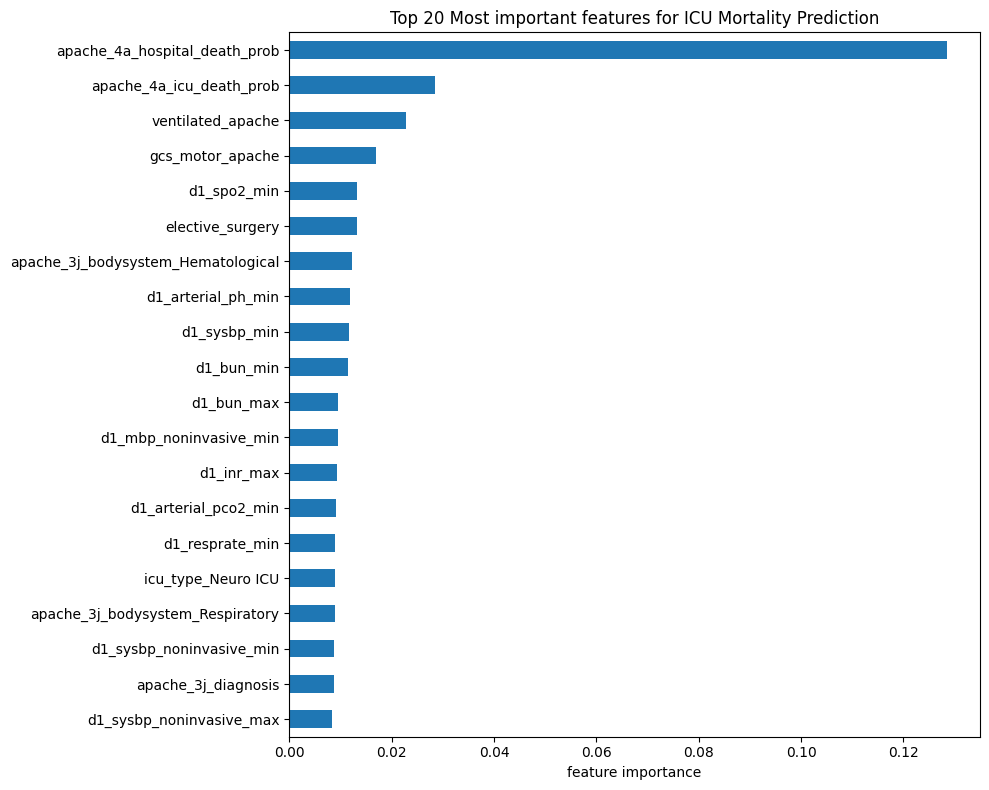

apache_4a_hospital_death_prob         0.128530
apache_4a_icu_death_prob              0.028515
ventilated_apache                     0.022838
gcs_motor_apache                      0.016878
d1_spo2_min                           0.013310
elective_surgery                      0.013193
apache_3j_bodysystem_Hematological    0.012310
d1_arterial_ph_min                    0.011788
d1_sysbp_min                          0.011761
d1_bun_min                            0.011433
d1_bun_max                            0.009612
d1_mbp_noninvasive_min                0.009496
d1_inr_max                            0.009411
d1_arterial_pco2_min                  0.009170
d1_resprate_min                       0.008989
icu_type_Neuro ICU                    0.008922
apache_3j_bodysystem_Respiratory      0.008907
d1_sysbp_noninvasive_min              0.008715
apache_3j_diagnosis                   0.008653
d1_sysbp_noninvasive_max              0.008446
dtype: float32


In [24]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(xgb.feature_importances_, index=X.columns)
top20 = feature_importance.nlargest(20)

plt.figure(figsize=(10, 8))
top20.sort_values().plot(kind='barh')
plt.title('Top 20 Most important features for ICU Mortality Prediction')
plt.xlabel('feature importance')
plt.tight_layout()
plt.show()

print(top20)

In [25]:
# remove apache probability scores
cols_to_remove = ['apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob']
X_train_no_apache = X_train.drop(columns=cols_to_remove)
X_test_no_apache = X_test.drop(columns=cols_to_remove)

xgb_no_apache = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=83798/7915,
    random_state=42,
    eval_metric='auc'
)

xgb_no_apache.fit(X_train_no_apache, y_train,
                  eval_set=[(X_test_no_apache, y_test)],
                  verbose=100)

y_prob_no_apache = xgb_no_apache.predict_proba(X_test_no_apache)[:, 1]
y_pred_no_apache = xgb_no_apache.predict(X_test_no_apache)

print(classification_report(y_test, y_pred_no_apache, target_names=['Survived', 'Died']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_no_apache):.4f}')

[0]	validation_0-auc:0.83232
[100]	validation_0-auc:0.89635
[200]	validation_0-auc:0.90133
[300]	validation_0-auc:0.90206
[400]	validation_0-auc:0.90146
[499]	validation_0-auc:0.90071
              precision    recall  f1-score   support

    Survived       0.97      0.89      0.93     16760
        Died       0.38      0.71      0.50      1583

    accuracy                           0.87     18343
   macro avg       0.68      0.80      0.71     18343
weighted avg       0.92      0.87      0.89     18343

AUC-ROC: 0.9007


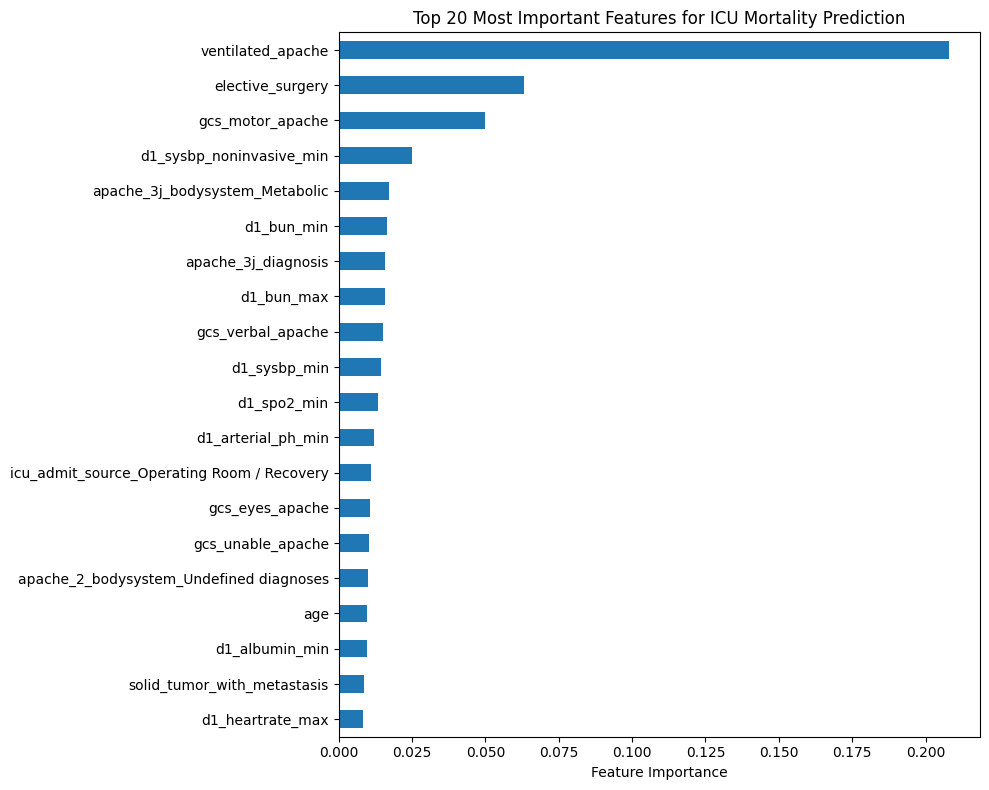

ventilated_apache                             0.208150
elective_surgery                              0.063334
gcs_motor_apache                              0.049960
d1_sysbp_noninvasive_min                      0.025094
apache_3j_bodysystem_Metabolic                0.017148
d1_bun_min                                    0.016343
apache_3j_diagnosis                           0.015970
d1_bun_max                                    0.015872
gcs_verbal_apache                             0.015182
d1_sysbp_min                                  0.014523
d1_spo2_min                                   0.013547
d1_arterial_ph_min                            0.012205
icu_admit_source_Operating Room / Recovery    0.010934
gcs_eyes_apache                               0.010838
gcs_unable_apache                             0.010335
apache_2_bodysystem_Undefined diagnoses       0.009945
age                                           0.009644
d1_albumin_min                                0.009570
solid_tumo

In [27]:
X_no_apache = X.drop(columns=['apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob'])
feat_importance = pd.Series(xgb_no_apache.feature_importances_, index=X_no_apache.columns)
top20 = feat_importance.nlargest(20)

plt.figure(figsize=(10, 8))
top20.sort_values().plot(kind='barh')
plt.title('Top 20 Most Important Features for ICU Mortality Prediction')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print(top20)

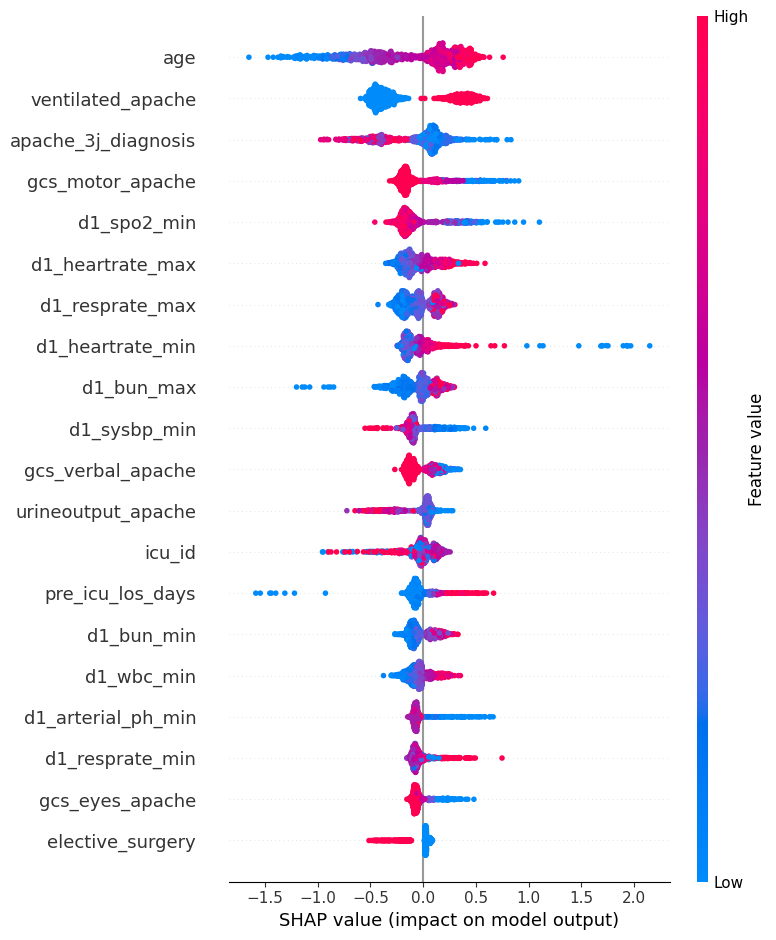

In [30]:
import shap
explainer = shap.TreeExplainer(xgb_no_apache)

X_test_sample = X_test_no_apache.iloc[:1000]
shap_values=explainer.shap_values(X_test_sample)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()